Notebook utilizado para generar un conjunto de datos con data drift a partir de los datos limpios utilizados para entrenar el modelo. El notebook fue desarrollado en google colab.

In [3]:
# Install required libraries
%pip install numpy pandas matplotlib seaborn scikit-learn alibi-detect

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.mixture import GaussianMixture # Para hacer datos sintéticos que van a simular datos que están desplazados
from alibi_detect.cd import KSDrift

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/MLOps/FASE_3/'

In [7]:
from google.colab import userdata

github_token = userdata.get("github_token")

if not github_token:
  raise ValueError("Token no encontrado en los secretos")

In [8]:
# Clonamos repo de GitHub completo
!git clone https://$github_token@github.com/TecMNA2025MLOpsEq25/mna-mlops-sep2025-eq25.git

Cloning into 'mna-mlops-sep2025-eq25'...
remote: Enumerating objects: 638, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 638 (delta 140), reused 176 (delta 98), pack-reused 405 (from 1)
Receiving objects: 100% (638/638), 4.69 MiB | 7.29 MiB/s, done.
Resolving deltas: 100% (259/259), done.


In [9]:
# Agregamos la ruta de la función que limpia la información al system que contiene las funciones
import sys
repo_path = "/content/mna-mlops-sep2025-eq25"
if repo_path not in sys.path:
    sys.path.append(repo_path)

In [10]:
# Load the Dataset and Generate Descriptive Statistics
df = pd.read_csv(path + 'obesity_estimation_original.csv')
# df['target'] = wine.target

# Display the first few rows of the dataset
print('First few rows of the dataset:')
display(df.head())

# Generate descriptive statistics
print('\nDescriptive statistics of the dataset:')
display(df.describe())

First few rows of the dataset:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Descriptive statistics of the dataset:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [12]:
# Limpieza de la información con el script dataset.py (https://github.com/TecMNA2025MLOpsEq25/mna-mlops-sep2025-eq25/blob/master/obesity_estimator/dataset.py)

from obesity_estimator.dataset import clean_data, save_data

df_clean = clean_data(df)

In [13]:
# Guardamos la información limpia

df_clean.to_csv(path + "df_limpio.csv", index=False)

In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   Int64  
 5   FAVC                            2087 non-null   Int64  
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   object 
 9   SMOKE                           2087 non-null   Int64  
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   Int64  
 12  FAF                             2087 no

In [15]:
display(df_clean.head())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,female,21.0,1.62,64.0,1,0,2.0,3.0,sometimes,0,2.0,0,0.0,1.0,no,public_transportation,normal_weight
1,female,21.0,1.52,56.0,1,0,3.0,3.0,sometimes,1,3.0,1,3.0,0.0,sometimes,public_transportation,normal_weight
2,male,23.0,1.80,77.0,1,0,2.0,3.0,sometimes,0,2.0,0,2.0,1.0,frequently,public_transportation,normal_weight
3,male,27.0,1.80,87.0,0,0,3.0,3.0,sometimes,0,2.0,0,2.0,0.0,frequently,walking,overweight_level_i
4,male,22.0,1.78,89.8,0,0,2.0,1.0,sometimes,0,2.0,0,0.0,0.0,sometimes,public_transportation,overweight_level_ii


In [16]:
variables = [col for col in df_clean.columns if col != 'NObeyesdad']
df_clean[variables]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,female,21.000000,1.620000,64.000000,1,0,2.0,3.0,sometimes,0,2.000000,0,0.000000,1.000000,no,public_transportation
1,female,21.000000,1.520000,56.000000,1,0,3.0,3.0,sometimes,1,3.000000,1,3.000000,0.000000,sometimes,public_transportation
2,male,23.000000,1.800000,77.000000,1,0,2.0,3.0,sometimes,0,2.000000,0,2.000000,1.000000,frequently,public_transportation
3,male,27.000000,1.800000,87.000000,0,0,3.0,3.0,sometimes,0,2.000000,0,2.000000,0.000000,frequently,walking
4,male,22.000000,1.780000,89.800000,0,0,2.0,1.0,sometimes,0,2.000000,0,0.000000,0.000000,sometimes,public_transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,female,20.976842,1.710730,131.408528,1,1,3.0,3.0,sometimes,0,1.728139,0,1.676269,0.906247,sometimes,public_transportation
2107,female,21.982942,1.748584,133.742943,1,1,3.0,3.0,sometimes,0,2.005130,0,1.341390,0.599270,sometimes,public_transportation
2108,female,22.524036,1.752206,133.689352,1,1,3.0,3.0,sometimes,0,2.054193,0,1.414209,0.646288,sometimes,public_transportation
2109,female,24.361936,1.739450,133.346641,1,1,3.0,3.0,sometimes,0,2.852339,0,1.139107,0.586035,sometimes,public_transportation


In [17]:
df_clean.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [18]:
for col in ['family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']:
  print(f'{col}: {df_clean[col].unique()}')

family_history_with_overweight: <IntegerArray>
[1, 0]
Length: 2, dtype: Int64
FAVC: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
CAEC: ['sometimes' 'frequently' 'always' 'no']
SMOKE: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
SCC: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
CALC: ['no' 'sometimes' 'frequently' 'always']
MTRANS: ['public_transportation' 'walking' 'automobile' 'motorbike' 'bike']


In [19]:
df_clean.dtypes

,0
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,Int64
FAVC,Int64
FCVC,float64
NCP,float64
CAEC,object
SMOKE,Int64


In [20]:
numeric_drift_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

categorical_drift_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

In [21]:
def drift_gmm_numeric_column(df, col, meanshift=0.0, n_components=5, random_state=42, scale=1.0, shift=0.0, noise_std=0.0, clip=None, verbose=True):
  """
  Aplica drift a una columna numérica por pasos:
  Paso 1: Aplica GMM con ajuste de medias (Meanshift)
  Paso 2: Transforma de acuerdo a los parámetros scale, shift, noise y clip

  Interpretación de parámetros:
  - meanshift: Factor multiplicativo sobre las medias del GMM (0.3 = +30%)
  - scale: factor multiplicativo sobre los valores generados
  - shift: desplazamiento aditivo de la distribución (ozquierda o derecha según sea el caso)
  - noise_std: Desviación estándar del ruido gaussiano
  - clip: tupla (min, max) que indica el rango de valores válidos
  """

  df_drift = df.copy()

  # Ajustamos GMM a la distribución original

  # Ajustamos el tipo de dato para la entrada del modelo
  X = df_drift[col].to_numpy().reshape(-1,1)
  # Generamos el modelo
  gmm = GaussianMixture(n_components=n_components, random_state=random_state)
  # Ajustamos el modelo
  gmm.fit(X)

  if verbose:
    print(f'\nColumna numérica: {col}')
    print('Original means: \n', gmm.means_.ravel())

  # Modificación de medias
  if meanshift != 0.0:
    # Genera copia de las medias originales
    modified_means = gmm.means_.copy()
    # Modificación de las componentes (vectorizada)
    modified_means *= (1 + meanshift)
    gmm.means_ = modified_means

  if verbose:
    print('Modified means: \n', gmm.means_.ravel())

  # Muestrear nuevos valores desde el GMM modificado
  n_samples = len(df_drift)
  synthetic_values, _ = gmm.sample(n_samples)
  synthetic_values = synthetic_values.reshape(-1)

  # Transformación aplicando scale, shift y noise
  X_new = synthetic_values.astype(float)
  X_new = synthetic_values * scale + shift + np.random.normal(0, noise_std, n_samples)

  if verbose:
    print('Transformación aplicada')

  if noise_std > 0:
    noise = np.random.normal(0, noise_std, size=len(X_new))
    X_new = X_new + noise

  if clip is not None:
    X_new = np.clip(X_new, clip[0], clip[1])

  df_drift[col] = X_new

  return df_drift

In [22]:
def drift_gmm_multiple_numeric_columns(df, numeric_config, verbose=True):
  """
  numeric_config = {
    "Age":  {"meanshift": -0.1, "scale": 1.0, "shift": 0.0, "noise_std": 1.0, "clip": (10, 80)},
    "TUE":  {"meanshift":  0.2, "scale": 1.1, "shift": 0.5, "noise_std": 0.3, "clip": (0, 24)},
    "CH2O": {"meanshift":  0.1, "scale": 1.0, "shift": 0.3, "noise_std": 0.1, "clip": (0, 5)}
  }
  """

  df_drift = df.copy()
  for i, (col, cfg) in enumerate(numeric_config.items()):
    df_drift = drift_gmm_numeric_column(df_drift, col, # **cfg,
                                        meanshift=cfg.get('meanshift', 0.0),
                                        n_components=cfg.get('n_components', 5),
                                        random_state=cfg.get('random_state', 42),
                                        scale=cfg.get('scale', 1.0),
                                        shift=cfg.get('shift', 0.0),
                                        noise_std=cfg.get('noise_std', 0.0),
                                        clip=cfg.get('clip', None),
                                        verbose=verbose)
  return df_drift

In [23]:
numeric_drift_config = {
    "Age": {
        "meanshift": -0.05,   # la población se hace ligeramente más joven
        "scale": 1.0,
        "shift": 0.0,
        "noise_std": 1.0,
        "clip": (10, 80),
    },
    "TUE": {
        "meanshift": 0.2,     # más horas frente a pantallas
        "scale": 1.1,
        "shift": 0.5,
        "noise_std": 0.3,
        "clip": (0, 24),
    },
    "CH2O": {
        "meanshift": 0.1,     # ligero aumento consumo de agua
        "scale": 1.0,
        "shift": 0.2,
        "noise_std": 0.1,
        "clip": (0, 5),
    },
    "FAF": {
        "meanshift": 0.1,     # población un poco más activa
        "scale": 1.0,
        "shift": 0.1,
        "noise_std": 0.2,
        "clip": (0, 7),
    },
}

df_num_drift = drift_gmm_multiple_numeric_columns(df_clean, numeric_drift_config, verbose=True)


Columna numérica: Age
Original means: 
 [31.20819009 24.17905378 50.18079976 19.51897705 38.62804216]
Modified means: 
 [29.64778059 22.97010109 47.67175977 18.5430282  36.69664006]
Transformación aplicada

Columna numérica: TUE
Original means: 
 [1.54581624e+00 5.11515620e-05 2.00000000e+00 5.70791130e-01
 9.99979066e-01]
Modified means: 
 [1.85497948e+00 6.13818744e-05 2.40000000e+00 6.84949356e-01
 1.19997488e+00]
Transformación aplicada

Columna numérica: CH2O
Original means: 
 [1.00007176 2.00001604 2.99999661 2.42780286 1.49364052]
Modified means: 
 [1.10007894 2.20001764 3.29999627 2.67058315 1.64300457]
Transformación aplicada

Columna numérica: FAF
Original means: 
 [2.66503474e-05 1.82577752e+00 9.76616675e-01 2.99998570e+00
 2.92826902e-01]
Modified means: 
 [2.93153821e-05 2.00835527e+00 1.07427834e+00 3.29998427e+00
 3.22109592e-01]
Transformación aplicada


In [24]:
df_num_drift.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,female,29.092136,1.62,64.0,1,0,2.0,3.0,sometimes,0,1.510721,0,0.354242,2.311440,no,public_transportation,normal_weight
1,female,29.709749,1.52,56.0,1,0,3.0,3.0,sometimes,1,1.200800,1,0.261719,2.675689,sometimes,public_transportation,normal_weight
2,male,26.741281,1.80,77.0,1,0,2.0,3.0,sometimes,0,1.292033,0,0.000000,2.395835,frequently,public_transportation,normal_weight
3,male,27.972260,1.80,87.0,0,0,3.0,3.0,sometimes,0,1.303821,0,0.275937,2.154446,frequently,walking,overweight_level_i
4,male,22.945560,1.78,89.8,0,0,2.0,1.0,sometimes,0,1.254971,0,0.000000,2.280793,sometimes,public_transportation,overweight_level_ii


In [25]:
def drift_categorical_column(df,col,new_distribution=None,frac_change=1.0,random_state=42,verbose=True):
  """
  Simula drift en una variable categórica cambiando:
    - La distribución objetivo de categorías (new_distribution)
    - La fracción de filas que serán alteradas (frac_change ~ noise a nivel fila)

  new_distribution: dict {categoria: peso} (se normaliza internamente)
  frac_change: 0<frac<=1, proporción de filas a las que se les reasigna categoría.
  """
  rng = np.random.default_rng(random_state)
  df_drift = df.copy()

  series = df_drift[col].astype("category")

  # Si no se pasa new_distribution, usamos la distribución original
  if new_distribution is None:
    probs_orig = series.value_counts(normalize=True)
    cats = probs_orig.index.to_list()
    probs = probs_orig.values
  else:
    cats = list(new_distribution.keys())
    probs = np.array(list(new_distribution.values()), dtype=float)
    probs = probs / probs.sum()

  if verbose:
    print(f"\nColumna categórica: {col}")
    print("Categorías:", cats)
    print("Probabilidades objetivo:", probs)

  n = len(df_drift)
  n_change = int(np.round(frac_change * n))

  # Índices a cambiar
  idx_to_change = rng.choice(df_drift.index, size=n_change, replace=False)

  # Muestreo de nuevas categorías según la dist. objetivo
  new_values = rng.choice(cats, size=n_change, p=probs)
  df_drift.loc[idx_to_change, col] = new_values

  return df_drift

In [26]:
def drift_multiple_categorical_columns(df, cat_config, verbose=True):
  """
  cat_config: dict {col: {"new_distribution": {...}, "frac_change": float}}

  Ejemplo:
    cat_config = {
      "FAVC": {"new_distribution": {"yes": 0.8, "no": 0.2},"frac_change": 0.7},
      "CAEC": {"new_distribution": {"no": 0.1,"Sometimes": 0.3,"Frequently": 0.4,"Always": 0.2},
      "frac_change": 0.6}
    }
  """
  df_drift = df.copy()
  for i, (col, cfg) in enumerate(cat_config.items()):
    df_drift = drift_categorical_column(df_drift,
                                        col,
                                        new_distribution=cfg.get("new_distribution", None),
                                        frac_change=cfg.get("frac_change", 1.0),
                                        random_state=cfg.get("random_state", 42 + i),
                                        verbose=verbose)
  return df_drift


In [27]:
cat_drift_config = {
  "FAVC": {
    # Más consumo de comida alta en calorías
    "new_distribution": {1: 0.8, 0: 0.2},
    "frac_change": 0.7,    # ~70% de filas potencialmente cambiadas
  },
  "CAEC": {
    # Más snacks entre comidas
    "new_distribution": {
      "no": 0.1,
      "Sometimes": 0.35,
      "Frequently": 0.35,
      "Always": 0.2,
      },
    "frac_change": 0.6,
  },
  "CALC": {
    # Ligero aumento consumo de alcohol
    "new_distribution": {
      "no": 0.4,
      "Sometimes": 0.4,
      "Frequently": 0.15,
      "Always": 0.05,
      },
    "frac_change": 0.5,
  },
}

df_cat_drift = drift_multiple_categorical_columns(df_num_drift, cat_drift_config, verbose=True)

# Dataset final con drift numérico + categórico
df_future = df_cat_drift.copy()


Columna categórica: FAVC
Categorías: [1, 0]
Probabilidades objetivo: [0.8 0.2]

Columna categórica: CAEC
Categorías: ['no', 'Sometimes', 'Frequently', 'Always']
Probabilidades objetivo: [0.1  0.35 0.35 0.2 ]

Columna categórica: CALC
Categorías: ['no', 'Sometimes', 'Frequently', 'Always']
Probabilidades objetivo: [0.4  0.4  0.15 0.05]


In [28]:
# Detect Data Drift using Alibi-Detect
# Kolmogorov-Smirnoff test

# Columnas numéricas para el df antes del drift
X_original = df_clean[numeric_drift_cols].to_numpy()

# Columnas numéricas para el df después del drift
X_synthetic = df_future[numeric_drift_cols].to_numpy()

print(X_original.shape, X_synthetic.shape)

(2087, 6) (2087, 6)


In [29]:
cd = KSDrift(X_original, p_val=0.05)

drift_pred = cd.predict(X_synthetic)

print('KS-Drift detected (global):', bool(drift_pred['data']['is_drift']))
p_vals = drift_pred['data']['p_val']  # array de tamaño = nº de columnas

alpha = 0.05
for col, p in zip(numeric_drift_cols, p_vals):
    is_drift_col = p < alpha
    print(f"{col:10s}  p_val = {p:.4f}  → drift = {is_drift_col}")

KS-Drift detected (global): True
Age         p_val = 0.0000  → drift = True
FCVC        p_val = 1.0000  → drift = False
NCP         p_val = 1.0000  → drift = False
CH2O        p_val = 0.0000  → drift = True
FAF         p_val = 0.0000  → drift = True
TUE         p_val = 0.0000  → drift = True


In [30]:
from scipy.stats import chi2_contingency

# Columnas numéricas para el df antes del drift
X_original = df_clean[numeric_drift_cols].to_numpy()

# Columnas numéricas para el df después del drift
X_synthetic = df_future[numeric_drift_cols].to_numpy()

cd = KSDrift(X_original, p_val=0.05)

drift_pred = cd.predict(X_synthetic)

ks_global_drift = bool(drift_pred["data"]["is_drift"])
ks_pvals = drift_pred["data"]["p_val"]

print("KS global drift detected:", ks_global_drift)

ks_df = pd.DataFrame({
    "feature": numeric_drift_cols,
    "ks_pval": ks_pvals
})
ks_df

KS global drift detected: True


,feature,ks_pval
0,Age,6.195152e-14
1,FCVC,1.000000e+00
2,NCP,1.000000e+00
3,CH2O,0.000000e+00
4,FAF,3.669680e-19
5,TUE,0.000000e+00


In [31]:
# PSI Numerico
def psi_numeric(expected, actual, buckets=10):
  expected = pd.Series(expected).dropna()
  actual = pd.Series(actual).dropna()

  # percentiles en baseline
  breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
  breakpoints = np.unique(breakpoints)
  if len(breakpoints) <= 2:
      return 0.0

  def get_bin_proportions(x, cuts):
    bins = pd.cut(x, cuts, include_lowest=True)
    counts = bins.value_counts().sort_index()
    props = counts / counts.sum()
    return props

  expected_props = get_bin_proportions(expected, breakpoints)
  actual_props = get_bin_proportions(actual, breakpoints)

  all_idx = expected_props.index.union(actual_props.index)
  expected_props = expected_props.reindex(all_idx, fill_value=0)
  actual_props = actual_props.reindex(all_idx, fill_value=0)

  eps = 1e-6
  expected_props = expected_props + eps
  actual_props = actual_props + eps

  psi_vals = (expected_props - actual_props) * np.log(expected_props / actual_props)
  return psi_vals.sum()


def psi_for_numeric_features(df_ref, df_new, numeric_cols, buckets=10):
  rows = []
  for col in numeric_cols:
    psi_val = psi_numeric(df_ref[col], df_new[col], buckets=buckets)
    rows.append({"feature": col, "psi": psi_val})
  return pd.DataFrame(rows)


psi_num_df = psi_for_numeric_features(df_clean, df_future, numeric_drift_cols, buckets=10)
psi_num_df


,feature,psi
0,Age,0.061142
1,FCVC,0.000000
2,NCP,0.000000
3,CH2O,1.706931
4,FAF,0.534991
5,TUE,0.829598


In [32]:
# PSI categórico
def psi_categorical(expected, actual):
  expected = pd.Series(expected).astype("category")
  actual = pd.Series(actual).astype("category")

  cats = list(set(expected.cat.categories).union(set(actual.cat.categories)))

  exp_counts = expected.value_counts(normalize=True).reindex(cats, fill_value=0)
  act_counts = actual.value_counts(normalize=True).reindex(cats, fill_value=0)

  eps = 1e-6
  exp_props = exp_counts + eps
  act_props = act_counts + eps

  psi_vals = (exp_props - act_props) * np.log(exp_props / act_props)
  return psi_vals.sum()


def psi_for_categorical_features(df_ref, df_new, cat_cols):
  rows = []
  for col in cat_cols:
    psi_val = psi_categorical(df_ref[col], df_new[col])
    rows.append({"feature": col, "psi": psi_val})
  return pd.DataFrame(rows)


psi_cat_df = psi_for_categorical_features(df_clean, df_future, categorical_drift_cols)
psi_cat_df

,feature,psi
0,Gender,0.000000
1,family_history_with_overweight,0.000000
2,FAVC,0.029493
3,CAEC,7.132396
4,SMOKE,0.000000
5,SCC,0.000000
6,CALC,3.995686
7,MTRANS,0.000000


In [33]:
# Chi cuadraad categóricas
def chi2_for_categorical_features(df_ref, df_new, cat_cols):
  rows = []
  for col in cat_cols:
    # Convertimos a string para evitar mezclar int/str
    ref_series = df_ref[col].astype("string")
    new_series = df_new[col].astype("string")

    ref_counts = ref_series.value_counts()
    new_counts = new_series.value_counts()

    # Unión de categorías SIN ordenar (evitamos comparar tipos)
    cats = list(set(ref_counts.index).union(set(new_counts.index)))

    # Vector de frecuencias alineado a las mismas categorías
    ref_vec = ref_counts.reindex(cats, fill_value=0).to_numpy()
    new_vec = new_counts.reindex(cats, fill_value=0).to_numpy()

    # Matriz 2 x k: filas = (ref, new)
    contingency = np.vstack([ref_vec, new_vec])

    # Si sólo hay una categoría o todo es cero, no tiene sentido el chi2
    if contingency.shape[1] <= 1 or contingency.sum() == 0:
        chi2_pval = np.nan
    else:
        chi2, chi2_pval, dof, exp = chi2_contingency(contingency)

    rows.append({
      "feature": col,
      "chi2_pval": chi2_pval
    })
  return pd.DataFrame(rows)

chi2_cat_df = chi2_for_categorical_features(df_clean, df_future, categorical_drift_cols)
chi2_cat_df

,feature,chi2_pval
0,Gender,1.000000e+00
1,family_history_with_overweight,1.000000e+00
2,FAVC,4.507961e-08
3,CAEC,0.000000e+00
4,SMOKE,1.000000e+00
5,SCC,1.000000e+00
6,CALC,5.517126e-194
7,MTRANS,1.000000e+00


In [34]:
numeric_summary = (ks_df.merge(psi_num_df, on="feature", how="left"))
numeric_summary["type"] = "numeric"

categorical_summary = (psi_cat_df.merge(chi2_cat_df, on="feature", how="left"))
categorical_summary["type"] = "categorical"

summary = pd.concat([numeric_summary, categorical_summary], ignore_index=True)

# Rellenar columnas que no aplican
if "chi2_pval" not in summary.columns:
    summary["chi2_pval"] = np.nan
if "ks_pval" not in summary.columns:
    summary["ks_pval"] = np.nan

# Umbrales típicos
alpha_ks = 0.05
alpha_chi2 = 0.05

# Reglas de dedo para PSI
def psi_flag(psi):
  if pd.isna(psi):
    return np.nan
  if psi < 0.1:
    return "sin_drift"
  elif psi < 0.25:
    return "moderado"
  else:
    return "fuerte"

summary["ks_drift"] = summary["ks_pval"].apply(lambda p: (p < alpha_ks) if pd.notna(p) else np.nan)

summary["chi2_drift"] = summary["chi2_pval"].apply(lambda p: (p < alpha_chi2) if pd.notna(p) else np.nan)

summary["psi_level"] = summary["psi"].apply(psi_flag)

summary = summary[["feature", "type", "ks_pval", "ks_drift", "psi", "psi_level", "chi2_pval", "chi2_drift"]].sort_values(["type", "feature"])

def psi_is_drift(level):
  if isinstance(level, str):
    return level in ["moderado", "fuerte"]
  return False

summary["any_drift"] = summary.apply(
    lambda row: (
        (row["ks_drift"] is True) or
        (row["chi2_drift"] is True) or
        psi_is_drift(row["psi_level"])
    ),
    axis=1
)

display(summary)

,feature,type,ks_pval,ks_drift,psi,psi_level,chi2_pval,chi2_drift,any_drift
9,CAEC,categorical,NaN,NaN,7.132396,fuerte,0.000000e+00,True,True
12,CALC,categorical,NaN,NaN,3.995686,fuerte,5.517126e-194,True,True
8,FAVC,categorical,NaN,NaN,0.029493,sin_drift,4.507961e-08,True,True
6,Gender,categorical,NaN,NaN,0.000000,sin_drift,1.000000e+00,False,False
13,MTRANS,categorical,NaN,NaN,0.000000,sin_drift,1.000000e+00,False,False
11,SCC,categorical,NaN,NaN,0.000000,sin_drift,1.000000e+00,False,False
10,SMOKE,categorical,NaN,NaN,0.000000,sin_drift,1.000000e+00,False,False
7,family_history_with_overweight,categorical,NaN,NaN,0.000000,sin_drift,1.000000e+00,False,False
0,Age,numeric,6.195152e-14,True,0.061142,sin_drift,NaN,NaN,True
3,CH2O,numeric,0.000000e+00,True,1.706931,fuerte,NaN,NaN,True


In [35]:
summary[['feature', 'any_drift']]

,feature,any_drift
9,CAEC,True
12,CALC,True
8,FAVC,True
6,Gender,False
13,MTRANS,False
11,SCC,False
10,SMOKE,False
7,family_history_with_overweight,False
0,Age,True
3,CH2O,True


In [44]:
import math
from pandas.api.types import is_numeric_dtype

def plot_all_columns_drift(
  df_base,
  df_drift,
  summary=None,
  cols=None,
  n_cols_per_row=4,
  figsize_per_plot=(5, 4),
):
  """
  df_base: DataFrame baseline (ej. df_clean)
  df_drift: DataFrame con drift (ej. df_future / synthetic_data)
  summary: DataFrame con columnas ['feature', 'any_drift'] (opcional)
  cols: lista de columnas a graficar; si None, usa la intersección de columnas
  n_cols_per_row: número de subplots por fila
  figsize_per_plot: tamaño aproximado por subplot (width, height)
  """
  # Columnas a usar
  if cols is None:
    cols = [c for c in df_base.columns if c in df_drift.columns]

  n_features = len(cols)
  n_rows = math.ceil(n_features / n_cols_per_row)

  # Mapa de drift desde summary (si está disponible)
  drift_map = {}
  if summary is not None and "feature" in summary.columns and "any_drift" in summary.columns:
    drift_map = summary.set_index("feature")["any_drift"].to_dict()

  # Crear figura
  fig, axes = plt.subplots(
    n_rows,
    n_cols_per_row,
    figsize=(figsize_per_plot[0] * n_cols_per_row, figsize_per_plot[1] * n_rows),
    squeeze=False
  )
  axes_flat = axes.flatten()

  for ax, col in zip(axes_flat, cols):
    print(col)
    # Datos de referencia y con drift
    s_ref = df_base[col].dropna()
    s_new = df_drift[col].dropna()

    # -------- Detección de tipo: numérica continua vs categórica --------
    # Usamos el detector de pandas para evitar problemas con Int64Dtype, etc.
    # Además exigimos >5 valores únicos para tratarla como numérica continua.
    is_num_col = is_numeric_dtype(s_ref) and s_ref.nunique() > 5

    if is_num_col:
      # -------- Numéricas: KDE (y fallback a hist si falla) --------
      try:
        sns.kdeplot(s_ref, fill=True, ax=ax, label="Base", alpha=0.6)
        sns.kdeplot(s_new, fill=True, ax=ax, label="Drift", alpha=0.6)
      except Exception:
        # Por si KDE falla (p.ej. por datos constantes), usar hist
        ax.hist(s_ref, bins=30, density=True, alpha=0.5, label="Base")
        ax.hist(s_new, bins=30, density=True, alpha=0.5, label="Drift")
      ax.set_ylabel("Densidad")

    else:
      # -------- Categóricas (incluye binarias) --------
      # Convertimos a string para evitar problemas de mezcla de tipos
      s_ref_cat = s_ref.astype("string")
      s_new_cat = s_new.astype("string")

      ref_counts = s_ref_cat.value_counts(normalize=True)
      new_counts = s_new_cat.value_counts(normalize=True)

      cats = sorted(set(ref_counts.index).union(set(new_counts.index)))
      ref_vals = ref_counts.reindex(cats, fill_value=0.0)
      new_vals = new_counts.reindex(cats, fill_value=0.0)

      x = np.arange(len(cats))
      width = 0.4

      ax.bar(x - width/2, ref_vals.values, width, label="Base", alpha=0.7)
      ax.bar(x + width/2, new_vals.values, width, label="Drift", alpha=0.7)

      ax.set_xticks(x)
      ax.set_xticklabels(cats, rotation=45, ha="right")
      ax.set_ylabel("Proporción")

    # -------- Título con información de drift --------
    drift_flag = drift_map.get(col, None)
    if drift_flag is True:
      drift_text = "Drift detectado"
    elif drift_flag is False:
      drift_text = "Sin drift detectado"
    else:
      drift_text = "Drift no evaluado"

    ax.set_title(f"{col} – {drift_text}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

  # Ocultar ejes sobrantes si hay menos features que subplots
  for ax in axes_flat[n_features:]:
    ax.set_visible(False)

  plt.tight_layout()
  plt.show()

Gender
Age
Height
Weight
family_history_with_overweight
FAVC
FCVC
NCP
CAEC
SMOKE
CH2O
SCC
FAF
TUE
CALC
MTRANS
NObeyesdad


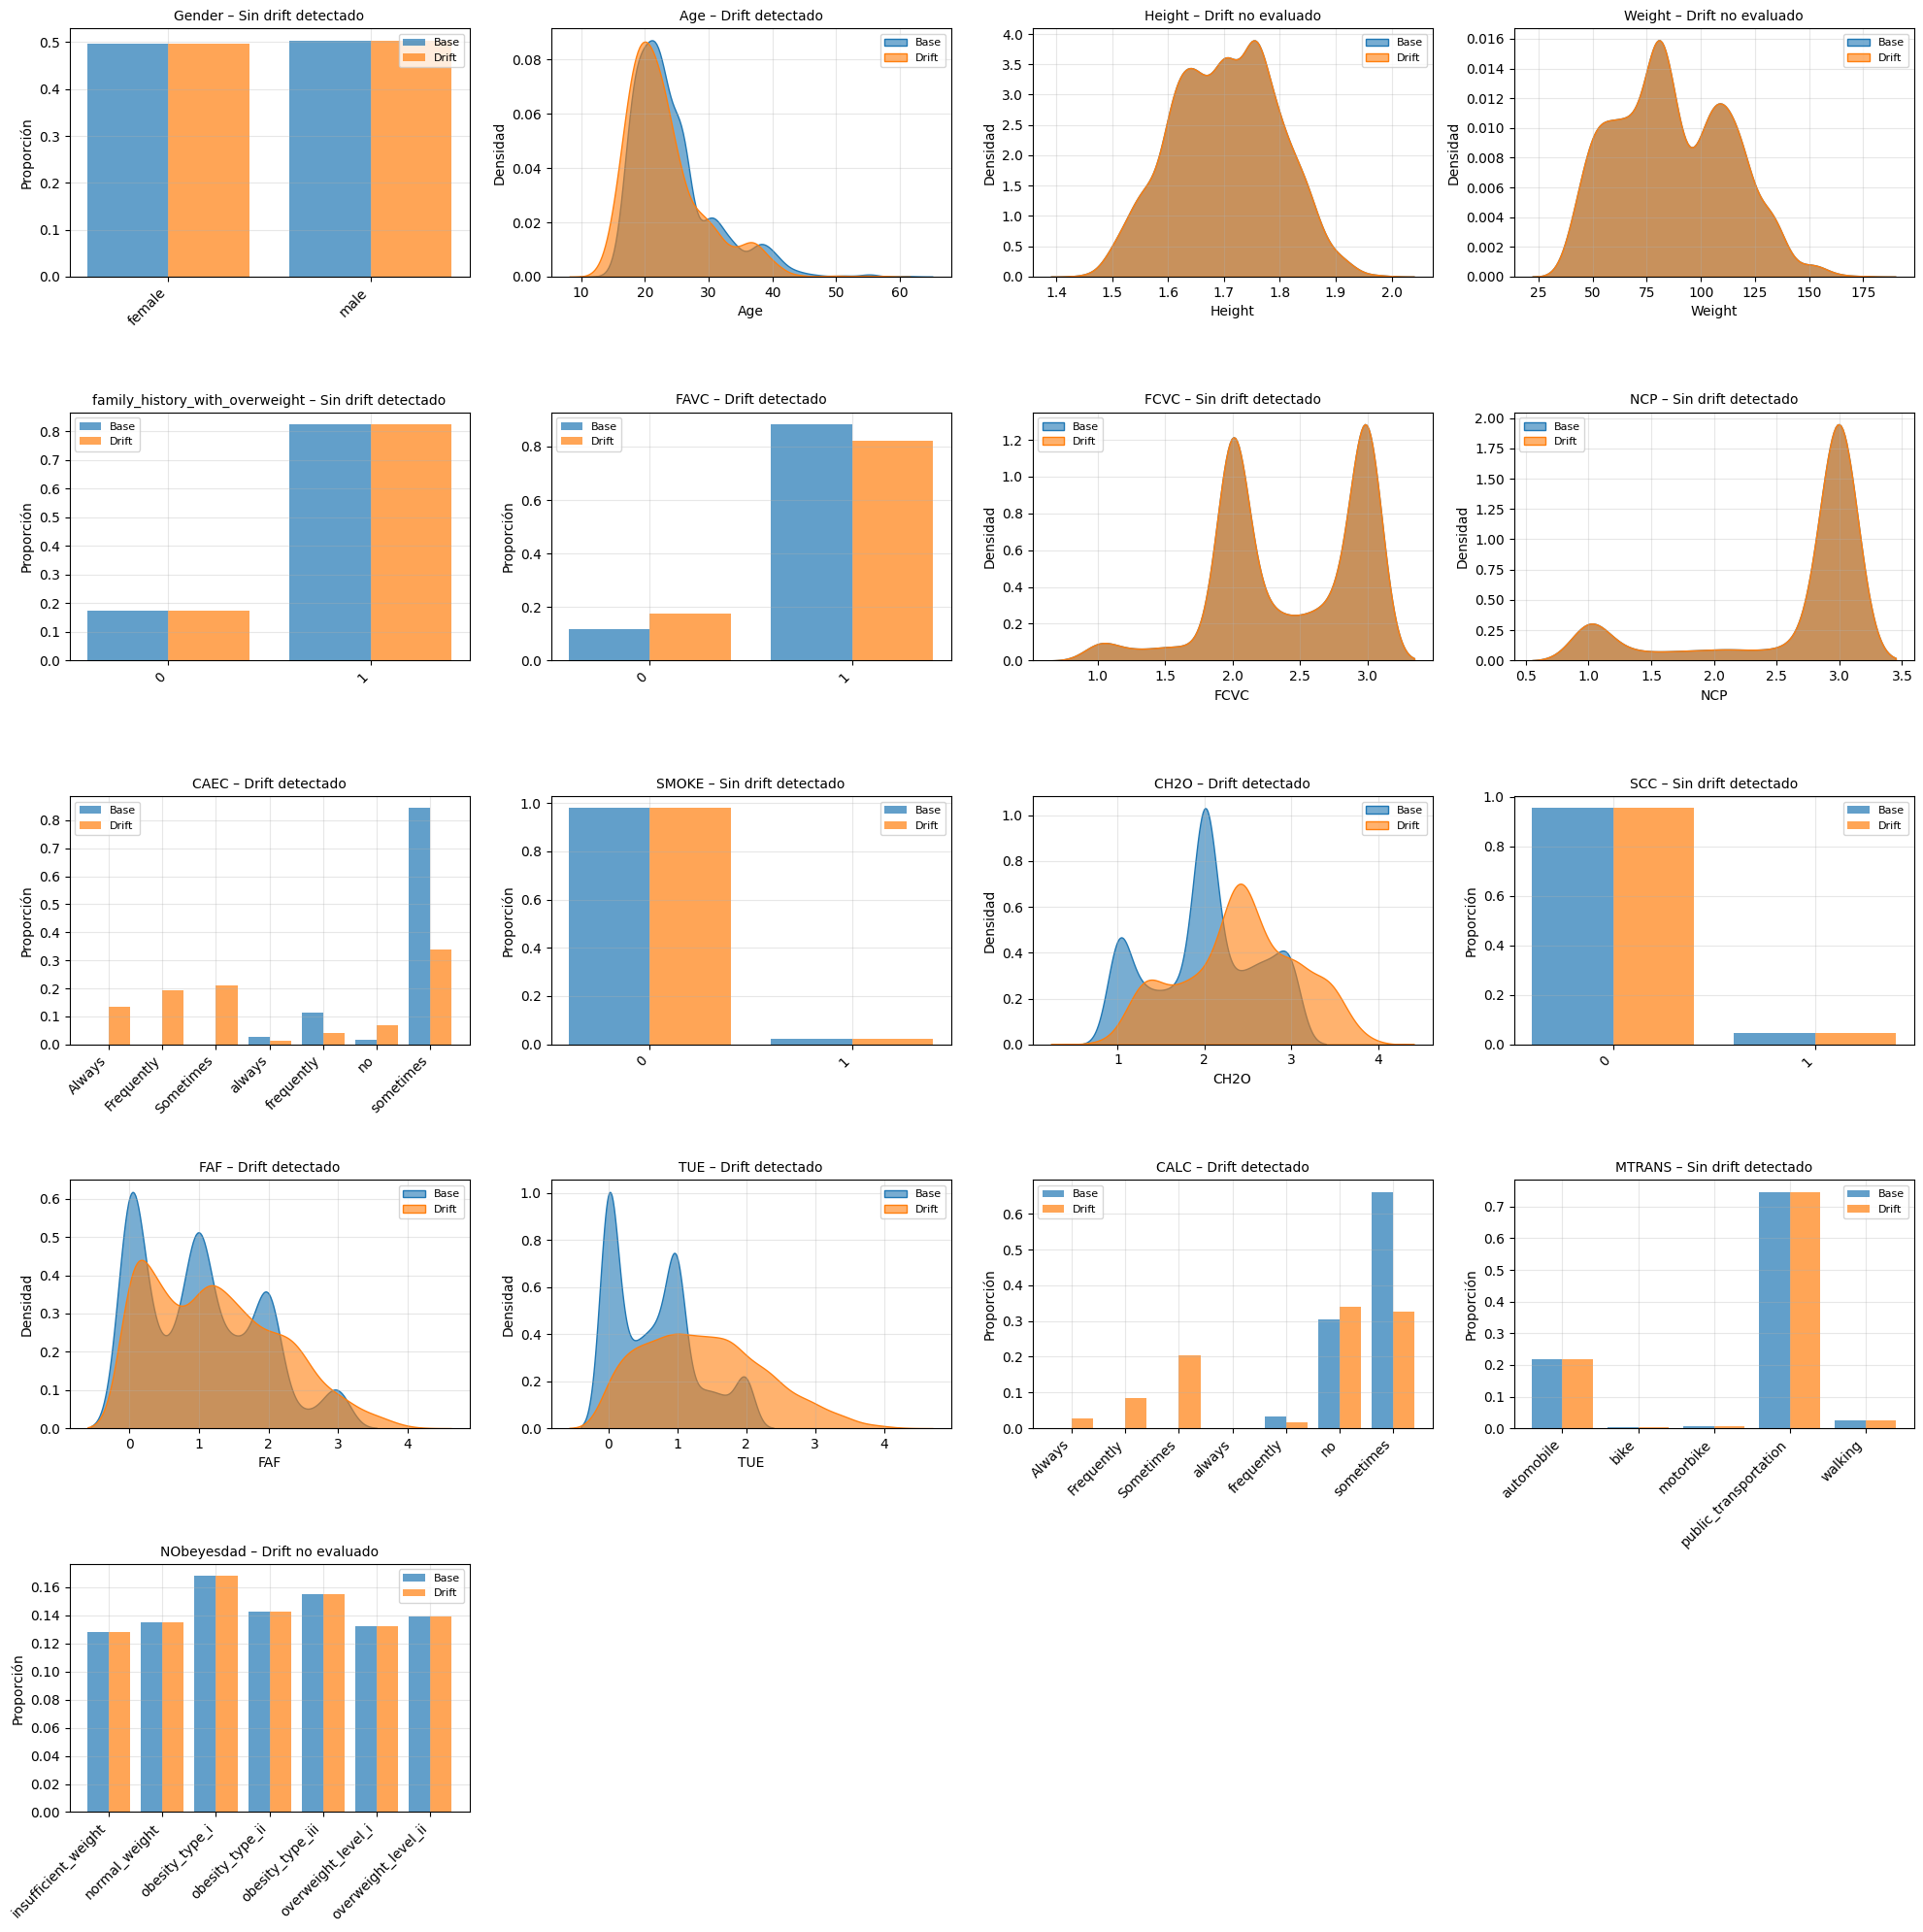

In [45]:
plot_all_columns_drift(df_base=df_clean,df_drift=df_future,summary=summary)

In [46]:
df_future.to_csv(path + 'df_drift.csv', index=False)